In [22]:
import os
import re
import json
from typing import Optional
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, field_validator

import httpx
from dotenv import load_dotenv
from langgraph.graph import StateGraph, END

load_dotenv()


True

In [23]:

class LeadData(BaseModel):
    name: Optional[str] = None
    email: Optional[str] = None
    mobile: Optional[str] = None
    requirement: Optional[str] = None

    def missing_fields(self) -> list[str]:
        missing = []
        if not self.name:       missing.append("name")
        if not self.email:      missing.append("email")
        if not self.mobile:     missing.append("mobile number")
        if not self.requirement: missing.append("requirement")
        return missing

    def is_complete(self) -> bool:
        return all([self.name, self.email, self.mobile, self.requirement])

    def filled_summary(self) -> str:
        parts = []
        if self.name:        parts.append(f"name: {self.name}")
        if self.email:       parts.append(f"email: {self.email}")
        if self.mobile:      parts.append(f"mobile: {self.mobile}")
        if self.requirement: parts.append(f"requirement: {self.requirement}")
        return ", ".join(parts) if parts else "none"

    @field_validator("email", mode="before")
    @classmethod
    def validate_email(cls, v):
        if v is None: return v
        if not re.match(r"^[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}$", v):
            raise ValueError(f"Invalid email: {v}")
        return v.lower().strip()

    @field_validator("mobile", mode="before")
    @classmethod
    def validate_mobile(cls, v):
        if v is None: return v
        digits = re.sub(r"[\s\-\+\(\)]", "", str(v))
        if not re.match(r"^\d{7,15}$", digits):
            raise ValueError(f"Invalid mobile: {v}")
        return digits

    @field_validator("name", mode="before")
    @classmethod
    def validate_name(cls, v):
        if v is None: return v
        v = v.strip()
        if len(v) < 2: raise ValueError("Name too short")
        return v

In [24]:
class AgentState(TypedDict):
    # conversation
    messages: list[dict]          # full chat history {role, content}
    user_input: str               # latest user message

    # routing
    intent: str                   # "product_query" | "follow_up" | "closing" | "irrelevant"
    product_query: str            # refined query if intent == product_query
    product_results: list[dict]   # results from vector store

    # lead
    lead: LeadData

In [25]:

async def call_llm(messages: list[dict], system: str = "", max_tokens: int = 500) -> str:
    payload_messages = []
    if system:
        payload_messages.append({"role": "system", "content": system})
    payload_messages.extend(messages)

    async with httpx.AsyncClient(timeout=30) as client:
        resp = await client.post(
            "https://openrouter.ai/api/v1/chat/completions",
            headers={
                "Authorization": f"Bearer {os.environ.get('OPENROUTER_API_KEY', '')}",
                "Content-Type": "application/json",
            },
            json={
                "model": "openai/gpt-4o-mini",
                "messages": payload_messages,
                "temperature": 0.2,
                "max_tokens": max_tokens,
            },
        )
        resp.raise_for_status()
    return resp.json()["choices"][0]["message"]["content"].strip()


In [26]:
def parse_json(text: str) -> dict:
    text = re.sub(r"```(?:json)?", "", text).strip().rstrip("`").strip()
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if m:
            return json.loads(m.group())
        return {}


In [27]:
def user_input_node(state: AgentState) -> AgentState:
    """
    Appends the latest user message to history.
    In a real app this is handled by the API layer.
    """
    state["messages"].append({"role": "user", "content": state["user_input"]})
    return state


In [28]:

CLASSIFY_SYSTEM = """
You are the brain of a sales assistant chatbot.

Given the conversation history and the latest user message, return a JSON with:
{
  "intent": "product_query" | "follow_up" | "closing" | "irrelevant",
  "product_query_text": "<refined search query if product_query, else null>",
  "name": "<extracted name or null>",
  "email": "<extracted email or null>",
  "mobile": "<extracted mobile number or null>",
  "requirement": "<what user is looking for or null>"
}

Intent definitions:
- product_query: user asking about a product, feature, pricing, or comparison
- follow_up: user has a follow-up question about something already discussed regarding products
- closing: user signals end (ok, thanks, sounds good, got it, perfect, that's all, etc.) or shows intrest in next steps (demo, trial, contact)
- irrelevant: completely off-topic (sports, weather, etc.)

Return ONLY the JSON object. No explanation.
"""

In [29]:
async def classify_node(state: AgentState) -> AgentState:
    raw = await call_llm(
        messages=state["messages"],
        system=CLASSIFY_SYSTEM,
        max_tokens=300,
    )
    
    parsed = parse_json(raw)

    state["intent"] = parsed.get("intent", "follow_up")
    state["product_query"] = parsed.get("product_query_text") or state["user_input"]

    # Merge extracted lead fields into existing LeadData — skip already-filled fields
    lead = state["lead"]

    print("\n------ lead ---------\n", lead)
    
    for field in ("name", "email", "mobile", "requirement"):
        value = parsed.get(field)
        if value and not getattr(lead, field):
            try:
                updated = lead.model_copy(update={field: value})
                setattr(lead, field, getattr(updated, field))
            except Exception as e:
                print(f"  [lead validation] {field} skipped: {e}")
    state["lead"] = lead

    print(f"  → intent: {state['intent']}")
    print(f"  → lead so far: {lead.filled_summary()}")
    return state

In [30]:
from mcp import ClientSession
from mcp.client.stdio import stdio_client
import json
from mcp.client.sse import sse_client

In [31]:
MCP_URL = "http://localhost:8001/sse"

async def call_mcp_tool(tool_name: str, arguments: dict) -> str:
    async with sse_client(url=MCP_URL) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            result = await session.call_tool(tool_name, arguments)
            return result.content[0].text

In [43]:
# Quick connectivity check
import httpx
print(httpx.get("http://localhost:8001/health").json())
# print(resp.status_code)  # should not raise a connection error

{'status': 'ok', 'service': 'SalesBot'}


In [33]:
result = await call_mcp_tool("get_product_info", {"query": "sales trigger monitoring"})
print(result)

Product: SalesTriggerAlert
A real-time sales trigger monitoring tool that alerts reps when a target account experiences a relevant business event — such as a funding round, leadership change, new job posting, product launch, or technology adoption. Helps reps reach out at exactly the right moment with contextually relevant messaging to improve response rates.

Product: SalesIntelDB
A B2B sales intelligence database covering over 50 million companies and 200 million contacts. Provides verified direct-dial phone numbers, email addresses, firmographic data, technographic data, and buying intent signals. Refreshed weekly to ensure data accuracy. Accessible via browser extension, web app, and API.

Product: ForecastIQ
An AI-powered sales forecasting tool that uses historical win rates, deal velocity, and rep activity data to generate highly accurate revenue predictions. Supports bottom-up and top-down forecasting methodologies, scenario planning, and commit vs. best-case vs. pipeline views.

In [34]:

PRODUCT_SYSTEM = """
You are a helpful sales assistant. Answer the user's product query using ONLY
the product results provided below. Do not invent any products or features.
If nothing relevant is found, say so politely.

{product_context}
"""

async def product_node(state: AgentState) -> AgentState:
    # Call get_product_info via MCP instead of directly
    product_text = await call_mcp_tool(
        "get_product_info",
        {"query": state["product_query"]}
    )

    reply = await call_llm(
        messages=state["messages"],
        system=f"You are a helpful sales assistant. Answer using ONLY these products:\n\n{product_text}",
    )
    state["messages"].append({"role": "assistant", "content": reply})
    return state



In [35]:

FOLLOWUP_SYSTEM = """
You are a helpful and concise sales assistant. Continue the conversation naturally.
Answer follow-up questions based on what has already been discussed.
If the query is irrelevant to sales or products, politely redirect.
"""

async def followup_node(state: AgentState) -> AgentState:
    reply = await call_llm(
        messages=state["messages"],
        system=FOLLOWUP_SYSTEM,
    )
    state["messages"].append({"role": "assistant", "content": reply})
    print(f"  [followup_node] replied")
    return state

In [36]:

IRRELEVANT_SYSTEM = """
If the query is irrelevant to sales or products, reply with polite messages saying you can't help with that topic.
NOTE: Greetings are not cosidered irrelevant. If the user says "hi" or "hello", respond with a greeting and then ask how you can assist with sales or products.
"""

async def irrelevant_node(state: AgentState) -> AgentState:
    print("Entering irrelevant_node ...")
    reply = await call_llm(
        messages=state["messages"],
        system=IRRELEVANT_SYSTEM,
    )
    state["messages"].append({"role": "assistant", "content": reply})
    print(f"  [irrelevant_node] replied")
    return state

In [37]:
import aiosqlite
import logging
from pathlib import Path

DB_PATH = Path("salesbot.db")
logger = logging.getLogger(__name__)


async def init_db() -> None:
    async with aiosqlite.connect(DB_PATH) as db:
        await db.execute(
            """
            CREATE TABLE IF NOT EXISTS leads (
                id          INTEGER PRIMARY KEY AUTOINCREMENT,
                name        TEXT NOT NULL,
                email       TEXT NOT NULL,
                mobile      TEXT NOT NULL,
                requirement TEXT NOT NULL,
                conv_id     TEXT,
                created_at  DATETIME DEFAULT CURRENT_TIMESTAMP
            )
            """
        )
        await db.commit()
    logger.info("Database initialised at %s", DB_PATH)


async def save_lead(lead: LeadData, conv_id: str) -> int:
    async with aiosqlite.connect(DB_PATH) as db:
        cursor = await db.execute(
            """
            INSERT INTO leads (name, email, mobile, requirement, conv_id)
            VALUES (?, ?, ?, ?, ?)
            """,
            (lead.name, lead.email, lead.mobile, lead.requirement, conv_id),
        )
        await db.commit()
        lead_id = cursor.lastrowid
    logger.info("Lead saved: id=%s email=%s", lead_id, lead.email)
    return lead_id


async def lead_exists(email: str) -> bool:
    async with aiosqlite.connect(DB_PATH) as db:
        cursor = await db.execute(
            "SELECT 1 FROM leads WHERE email = ?", (email.lower().strip(),)
        )
        row = await cursor.fetchone()
    return row is not None


In [38]:

LEAD_SYSTEM = """
You are a sales assistant wrapping up a conversation.

Already captured lead info: {filled}
Still missing: {missing}

Ask the user ONLY for the missing fields in a natural, friendly way.
Do not ask for anything already captured.
If all fields are captured, thank the user and say a team member will be in touch.
"""


# ── Update lead_node to call capture_lead via MCP when lead is complete ───────
async def lead_node(state: AgentState) -> AgentState:
    lead = state["lead"]
    missing = lead.missing_fields()

    if lead.is_complete():
        # All fields collected — persist via MCP tool
        result = await call_mcp_tool("capture_lead", {
            "name":        lead.name,
            "email":       lead.email,
            "mobile":      lead.mobile,
            "requirement": lead.requirement,
        })
        reply = await call_llm(
            messages=state["messages"],
            system=f"Lead capture result: {result}. Thank the user warmly and say a team member will reach out.",
        )
    else:
        # Still collecting — ask only for missing fields
        reply = await call_llm(
            messages=state["messages"],
            system=(
                f"Already captured: {lead.filled_summary()}. "
                f"Politely ask only for: {', '.join(missing)}."
            ),
        )

    state["messages"].append({"role": "assistant", "content": reply})
    return state

In [39]:
def route(state: AgentState) -> str:
    intent = state["intent"]
    if intent == "product_query":
        return "product"
    if intent == "closing":
        return "lead"
    if intent == "follow_up": 
        return "followup"
    return "irrelevant"


In [40]:
graph = StateGraph(AgentState)

graph.add_node("user_input",  user_input_node)
graph.add_node("classify",    classify_node)
graph.add_node("product",     product_node)
graph.add_node("followup",    followup_node)
graph.add_node("lead",        lead_node)
graph.add_node("irrelevant",        irrelevant_node)

graph.set_entry_point("user_input")
graph.add_edge("user_input", "classify")

graph.add_conditional_edges(
    "classify",
    route,
    {
        "product":  "product",
        "followup": "followup",
        "lead":     "lead",
        "irrelevant": "irrelevant",
    },
)

graph.add_edge("product",  END)
graph.add_edge("followup", END)
graph.add_edge("lead",     END)
graph.add_edge("irrelevant", END)

app = graph.compile()

app

print("Graph compiled")

Graph compiled


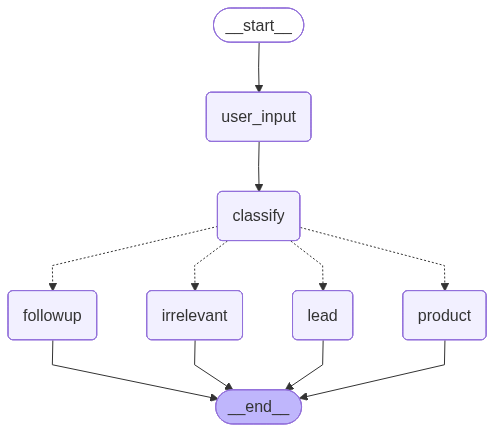

In [41]:
app

In [42]:
async def chat(user_message: str, state: AgentState) -> AgentState:
    print(f"\nUser: {user_message}")
    state["user_input"] = user_message
    state = await app.ainvoke(state)
    last_reply = next(
        m["content"] for m in reversed(state["messages"]) if m["role"] == "assistant"
    )
    print(f"Bot: {last_reply}")
    return state
1


state: AgentState = {
    "messages":        [],
    "user_input":      "",
    "intent":          "",
    "product_query":   "",
    "product_results": [],
    "lead":            LeadData(),
}

print("SalesBot ready. Type 'exit' to quit.\n")

while True:
    user_message = input("You: ").strip()
    if not user_message:
        continue
    if user_message.lower() == "exit":
        print("Goodbye!")
        break
    state = await chat(user_message, state)

    print("\n\n--- Conversation state ---\n", state, "\n-------------------------\n")

SalesBot ready. Type 'exit' to quit.


User: Hi

------ lead ---------
 name=None email=None mobile=None requirement=None
  → intent: irrelevant
  → lead so far: none
Entering irrelevant_node ...
  [irrelevant_node] replied
Bot: Hello! How can I assist you with sales or products today?


--- Conversation state ---
 {'messages': [{'role': 'user', 'content': 'Hi'}, {'role': 'assistant', 'content': 'Hello! How can I assist you with sales or products today?'}], 'user_input': 'Hi', 'intent': 'irrelevant', 'product_query': 'Hi', 'product_results': [], 'lead': LeadData(name=None, email=None, mobile=None, requirement=None)} 
-------------------------


User: I am looking for dunamic saless prcing

------ lead ---------
 name=None email=None mobile=None requirement=None
  → intent: product_query
  → lead so far: requirement: looking for dynamic sales pricing
Bot: For dynamic sales pricing, I recommend our **PriceOptimizer**. It is a dynamic pricing and discount management tool that provides AI-